In [ ]:
from preprocessing import segment_chart_region, extract_chart_line
import cv2
import os
from matplotlib import pyplot as plt

print(f"Current working directory: {os.getcwd()}")



In [25]:
output_dir = "../output/"
print(output_dir)
if not os.path.exists(output_dir):
    print(f"Output directory '{output_dir}' does not exist.")
    os.makedirs(output_dir)  # Optionally create the directory
    print(f"Created directory: {output_dir}")



../output/


In [26]:

image = cv2.imread("../test_charts/buy_ascending_triangle.png")
chart_box = segment_chart_region(image)
chart_line = extract_chart_line(image, chart_box)

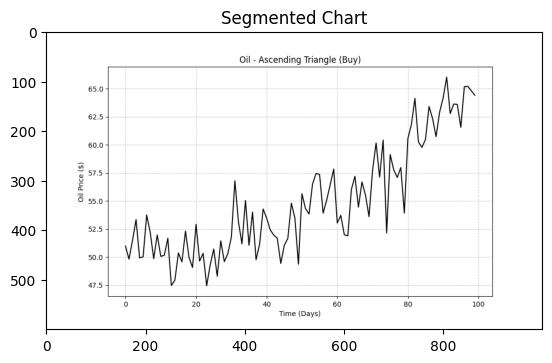

In [27]:
# Display the images in the notebook before saving


# Display original image
if image is not None:
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Segmented Chart")
    plt.show()




In [28]:

# Visualize results
cv2.rectangle(image, (chart_box[0], chart_box[1]), (chart_box[2], chart_box[3]), (0, 255, 0), 2)

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [  0, 255,   0]],

       ...,

       [[  0, 255,   0],
        [  0, 255,   0],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]]

In [29]:
# Validate 'image' data before writing
if image is not None:
    if not cv2.imwrite(os.path.join(output_dir, "segmented_chart.png"), image):
        raise RuntimeError("Failed to write 'segmented_chart.png'. Please check the input data or file path!")
else:
    raise ValueError("'image' is None. Ensure that the image is correctly processed before writing it.")

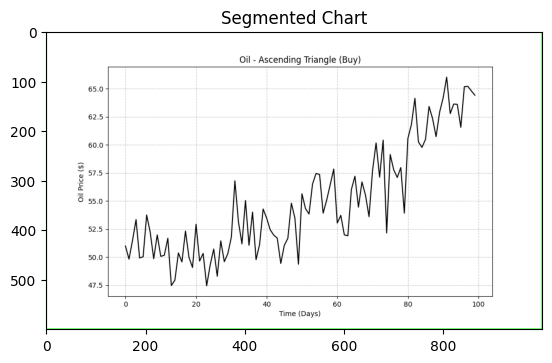

In [31]:

if image is not None:
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Segmented Chart")
    plt.show()


In [32]:

# Validate 'chart_line' data before writing
if chart_line is not None:
    if not cv2.imwrite(os.path.join(output_dir, "extracted_line.png"), chart_line):
        raise RuntimeError("Failed to write 'extracted_line.png'. Please check the input data or file path!")
else:
    raise ValueError("'chart_line' is None. Ensure that 'chart_line' is correctly processed before writing it.")


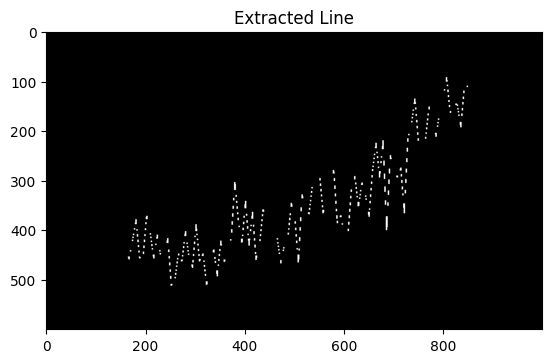

In [33]:
# Display the chart line
if chart_line is not None:
    plt.imshow(chart_line, cmap="gray")  # Update `cmap` as needed for 1-channel images
    plt.title("Extracted Line")
    plt.show()

In [34]:
from pattern_detection import detect_technical_patterns
import numpy as np

# Create synthetic price data with known patterns
prices = np.array([50, 52, 55, 53, 51, 53, 57, 55, 53, 51, 49, 47, 46, 45, 47, 50])
patterns = detect_technical_patterns(prices)
print("Detected patterns:", patterns)

Detected patterns: {}


In [39]:
from chart_analysis import analyze_chart

prices, patterns = analyze_chart("test_charts/new/hold_flat.png")
print("Detected patterns:", patterns)

FileNotFoundError: [Errno 2] No such file or directory: 'chart_model.pth'

In [36]:
from pattern_detection import detect_peaks_and_troughs, detect_double_bottom, detect_head_and_shoulders, detect_triangle
import numpy as np
import matplotlib.pyplot as plt

# Create synthetic price data with a clearer double bottom pattern
prices = np.array([50, 48, 46, 45, 47, 49, 48, 46, 45, 47, 50, 52, 54, 56])

# Debug the peak and trough detection
peaks, troughs, peak_props, trough_props = detect_peaks_and_troughs(prices, prominence=0.05, distance=2)

print("Peaks at indices:", peaks)
print("Troughs at indices:", troughs)

# Check individual pattern detection functions
is_double_bottom = detect_double_bottom(prices, peaks, troughs)
is_head_shoulders = detect_head_and_shoulders(prices, peaks, troughs)
triangle_type = detect_triangle(prices, peaks, troughs)

print(f"Double Bottom detected: {is_double_bottom}")
print(f"Head and Shoulders detected: {is_head_shoulders}")
print(f"Triangle pattern detected: {triangle_type}")

# Visualize the data with detected peaks and troughs
plt.figure(figsize=(10, 6))
plt.plot(prices, label='Price')
plt.scatter(peaks, prices[peaks], color='green', label='Peaks')
plt.scatter(troughs, prices[troughs], color='red', label='Troughs')
plt.legend()
plt.title('Price Data with Detected Peaks and Troughs')
plt.grid(True)
plt.savefig('detected_patterns.png')
plt.close()

# Try running the main detect_technical_patterns function
from pattern_detection import detect_technical_patterns
patterns = detect_technical_patterns(prices)
print("Detected patterns:", patterns)

Peaks at indices: [5]
Troughs at indices: [3 8]
Double Bottom detected: False
Head and Shoulders detected: False
Triangle pattern detected: None
Detected patterns: {}


In [37]:
# Double Bottom test data
double_bottom_data = np.array([50, 48, 45, 43, 45, 48, 46, 43, 42, 45, 48, 52, 55, 58])

# Head and Shoulders test data
head_shoulders_data = np.array([50, 52, 54, 52, 50, 52, 56, 60, 56, 52, 54, 58, 54, 50])

# Ascending Triangle test data
ascending_triangle_data = np.array([50, 52, 48, 50, 49, 52, 50, 52, 51, 52, 52, 53, 54, 55])

print("Testing with Double Bottom data:")
patterns = detect_technical_patterns(double_bottom_data)
print("Detected patterns:", patterns)

print("\nTesting with Head and Shoulders data:")
patterns = detect_technical_patterns(head_shoulders_data)
print("Detected patterns:", patterns)

print("\nTesting with Ascending Triangle data:")
patterns = detect_technical_patterns(ascending_triangle_data)
print("Detected patterns:", patterns)

Testing with Double Bottom data:
Detected patterns: {'Double Bottom': True}

Testing with Head and Shoulders data:
Detected patterns: {'Double Bottom': True}

Testing with Ascending Triangle data:
Detected patterns: {}
